In [3]:
%load_ext autoreload
%autoreload 2

from utils import *
plt.rcParams['figure.dpi'] = 100 

data = load_data("data")
trial_data_dict = {stim: extract_trials(data, stimulus=stim) for stim in STIMULI}

# 1 Binary Modulation

In [ ]:
EPSILON = 1e-12          # sign-safe MI denominator constant

modulation_results = run_binary_modulation_analysis(
    data,
    RESPONSE_WINDOWS,
    run_threshold=3.0,
    still_threshold=0.5,
    min_trials_per_state=2,
)


Each trial is assigned a behavioral state from its running-speed trace. 
- `Run` trials have mean speed above 3.0 cm/s with every frame above 0.5 cm/s; 
- `Still` trials have mean speed below 0.5 cm/s with every frame below 3.0 cm/s; 
- All remaining trials are ignored.

In [6]:
run_summary = summarize_binary_modulation_runs(modulation_results)
run_summary[["stimulus", "n_trials", "n_running", "n_still", "n_ignored"]]

,stimulus,n_trials,n_running,n_still,n_ignored
0,drifting_gratings,598,195,25,378
1,static_gratings,5811,1825,1910,2076
2,natural_scenes,5900,1315,1902,2683
3,spontaneous,1186,281,271,634


Both states are populated in every stimulus, so the running-versus-still contrast is defined throughout. The balance is strongly skewed for DG, which retains only 28 still trials against 195 running trials, whereas SG and NS retain thousands of each. DG estimates therefore rest on far less still data than the other stimuli.

## 1.1 Modulated neurons
Under different stimuli types, for each neuron, computed the average response of `run` trials $R_{\mathrm{run,c}}$ and `still` trials $R_{\mathrm{run,c}}$ for each conditions, then computed the evoked response $\Delta R_c$ for the conditions:
$$ \Delta R_c = R_{\mathrm{run, c}} - R_{\mathrm{still, c}}$$

Then gather together $\Delta R_c$ for all conditions under one stimuli type, test whether it is significantly different from 0, if so then the neuron is **modulated by running** under the stimuli type.

For `spont`, do Wilcoxon rank-sum test of all $R_{\mathrm{run}}$ and $R_{\mathrm{still}}$

<mark>The following analysis will be concentrated at the modulated neurons obtained here.</mark>

In [ ]:
# to obtain the modulated neurons under different stimuli (and spont)
...


In [ ]:
# to print out the modulated neurons for differernt stimuli
...

## 1.2 Sign-safe MI

For the modulated neurons, compute the sign-safe MI under different stimuli types:

$$
MI_{\mathrm{safe}} = \frac{R_{\mathrm{run}} - R_{\mathrm{still}}}
{|R_{\mathrm{run}}| + |R_{\mathrm{still}}| + \epsilon} \in [-1,1]
$$

with $\epsilon = 10^{-12}$ preventing division by zero. Its denominator is never negative, so MI_safe is bounded in [-1, 1] and always carries the sign of $R_{\mathrm{run}} - R_{\mathrm{still}}$. The denominator-free sensitivity measure is $\Delta R = R_{\mathrm{run}} - R_{\mathrm{still}}$.

> The original $MI=\frac{R_{\mathrm{run}} - R_{\mathrm{still}}} {R_{\mathrm{run}} + R_{\mathrm{still}}}$ suffers from negative values of responses ΔF/F, which shouldn't be simply removed as noise.

In [ ]:
# compute MI
... 

# plot the distribution (only for modualted neurons)


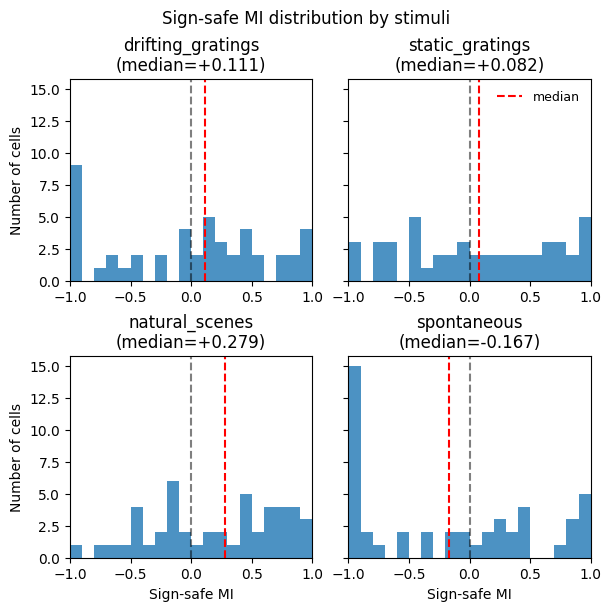

In [ ]:

# fig, axes = plt.subplots(2, 2, figsize=(6, 6),
#                          sharey=True, constrained_layout=True)
# axes = axes.ravel()
# for i, stimulus in enumerate(STIMULI):
#     ax = axes[i]
#     mi_safe, _, finite = compute_sign_safe_mi(modulation_results[stimulus], epsilon=EPSILON)
#     vals = mi_safe[finite]
#     median_safe = np.nanmedian(vals)

#     ax.hist(vals, bins=20, range=(-1, 1), alpha=0.8, color="C0")
#     ax.axvline(median_safe, linestyle="--", color="red", label=f"median")
#     ax.axvline(0, linestyle="--", color="black", alpha=0.5,)
#     ax.set_xlim(-1, 1)
#     ax.set_title(f"{stimulus}\n(median={median_safe:+.3f})")
#     if i%2==0:
#         ax.set_ylabel("Number of cells")
#     if i/2 >=1:
#         ax.set_xlabel("Sign-safe MI")

#     if i == 1:
#         ax.legend(frameon=False, fontsize=9)
# fig.suptitle("Sign-safe MI distribution by stimuli")

# # plt.savefig("doc/figures/MI_histogram_populations.png")
# plt.show()

> Median sign-safe MI is positive for all three visually evoked stimuli and negative for spontaneous activity, so running is associated with enhanced evoked responses but suppressed no-stimulus activity. Natural scenes show the largest median modulation and static gratings the smallest. 

> The effect is a **population tendency** rather than a universal one, since only 53 to 57 percent of cells are positive under evoked stimuli.

## 1.3 Gain analysis

For each modulated neuron under different stimuli, fits a simple gain model using run-still pairs of all conditions: 

$$
R_{\mathrm{run,c}} = a \cdot R_{\mathrm{still,c}} + b
$$

, where $a$ is the multiplicative slope, $b$ is the additive offset, and $R²$ measures how well one linear gain relation explains condition-level variation. 

A large slope does not imply a strong fit when $R²$ is low, because the line can pass through a widely scattered cloud of conditions. Spontaneous activity has no condition structure and is excluded.

In [15]:
# fit gain models only on modulated neurons 
...

# 2 Speed Tuning

Compute tuning *without* the `still` trials.

## 2.1 Tuning curve

In [ ]:
# compute the mean response of these neurons over conditions, regardless of running speed, to find the neurons' 'preferred condition' of each stimuli.
...

In [ ]:
# compute tuning on the preferred conditions, test the variance and monotonicity.
...

In [ ]:
# plot the tuning curve based on their tuning and monotonicity (non-tuned, pos, neg, non-mon) 3x4, with response during spont as baseline
...

## 2.2 Number and tuning profiles of modulated neurons

In [ ]:
# plot the number of modulated & tuned neurons
...

In [ ]:
# plot a huge grid map (cell # by stimuli), containing (i) modulated mask (ii) p-value of tuning variance (ii) colored rho
...